In [1]:
import pandas as pd
import numpy as np
import sklearn

In [125]:
ppt_stats = pd.read_csv('../../data/statistics/prism_msa_mean/ppt_msa_mean_2001-2015.csv')
tmean_stats = pd.read_csv('../../data/statistics/prism_msa_mean/tmean_msa_mean_2001-2015.csv')
tdmean_stats = pd.read_csv('../../data/statistics/prism_msa_mean/tdmean_msa_mean_2001-2015.csv')
sif_stats = pd.read_csv('../../data/statistics/green_indices_stats/sif_msa_mean.csv')
downscaled_nee_stats = pd.read_csv('../../data/statistics/downscaled_nee_msa_stats\downscaled_nee_msa_mean.csv')

ppt_stats.rename({'Unnamed: 0': 'msa'}, axis=1, inplace=True)
tmean_stats.rename({'Unnamed: 0': 'msa'}, axis=1, inplace=True)
tdmean_stats.rename({'Unnamed: 0': 'msa'}, axis=1, inplace=True)
sif_stats.rename({'Unnamed: 0': 'msa'}, axis=1, inplace=True)
downscaled_nee_stats.rename({'Unnamed: 0': 'msa'}, axis=1, inplace=True)

ppt_stats = ppt_stats.rename(columns={col: f"{col}_ppt" for col in ppt_stats.columns if col != "msa"})
tmean_stats = tmean_stats.rename(columns={col: f"{col}_tmean" for col in tmean_stats.columns if col != "msa"})
tdmean_stats = tdmean_stats.rename(columns={col: f"{col}_tdmean" for col in tdmean_stats.columns if col != "msa"})
sif_stats = sif_stats.rename(columns={col: f"{col}_sif" for col in sif_stats.columns if col != "msa"})
downscaled_nee_stats = downscaled_nee_stats.rename(columns={col: f"{col}_nee" for col in downscaled_nee_stats.columns if col != "msa"})

# Merge datasets on 'msa' column
df = ppt_stats.merge(tmean_stats, on="msa") \
              .merge(tdmean_stats, on="msa") \
              .merge(sif_stats, on="msa") \
              .merge(downscaled_nee_stats, on="msa")

df_long = df.melt(id_vars=['msa'], var_name='time', value_name='value')

# Separate target (NEE) and predictors
df_long['variable'] = df_long['time'].str.split('_').str[-1] 
df_long['time'] = df_long['time'].str.split('_').str[0]  

# Pivot table
df_pivot = df_long.pivot_table(index=['msa', 'time'], columns='variable', values='value').reset_index()

In [126]:
df_pivot

variable,msa,time,nee,ppt,sif,tdmean,tmean
0,"Abilene, TX Metro Area",200101,0.090420,41.225386,209.872659,-0.562452,4.687913
1,"Abilene, TX Metro Area",200102,-0.017733,74.936502,457.696629,3.188889,8.588515
2,"Abilene, TX Metro Area",200103,-0.171508,55.923560,1100.501873,3.851553,9.793486
3,"Abilene, TX Metro Area",200104,-0.696178,22.863401,2080.161049,10.829077,17.953254
4,"Abilene, TX Metro Area",200105,-0.272968,74.824850,1418.014981,14.146118,23.122622
...,...,...,...,...,...,...,...
64975,"Yuma, AZ Metro Area",201508,0.227905,6.447885,75.521978,13.166476,34.542191
64976,"Yuma, AZ Metro Area",201509,0.183135,22.917854,106.750916,13.199502,31.003187
64977,"Yuma, AZ Metro Area",201510,0.056134,15.970642,96.626374,9.162636,25.334064
64978,"Yuma, AZ Metro Area",201511,-0.036686,2.881659,26.549451,-3.402125,15.358903


### Fit ML Model

In [127]:
# Import libraries
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import warnings
import random

from scipy.integrate import odeint
from IPython.display import Image

# Sklearn specific functions used in this lecture
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import plot_tree
from sklearn.metrics import mean_squared_error, r2_score


# Suppress warnings
warnings.filterwarnings('ignore')

# Set number of decimals for np print options
np.set_printoptions(precision=3)


In [128]:
x_vars = ['ppt', 'tmean', 'tdmean', 'sif']
y_var = 'nee'
X = df_pivot[x_vars]
y = df_pivot[y_var]

In [129]:
len(X), len(y)

(64980, 64980)

In [131]:
random.seed(42)
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Decision Tree Regressor

In [151]:
# Initialize the Decision Tree Regressor
regressor = DecisionTreeRegressor(random_state=42)

# Train the regressor
regressor.fit(X_train, y_train)

# Make predictions on the test set
y_pred = regressor.predict(X_test)

In [152]:
results = pd.DataFrame(np.column_stack((y_pred,y_test)), columns= ['y_pred', 'y_test'])
print(results)

         y_pred    y_test
0      0.268083  0.407647
1     -0.897338 -1.833796
2     -0.773560 -0.609426
3     -2.531728 -3.698444
4      1.153344 -0.227287
...         ...       ...
12991  0.921789  0.849651
12992 -2.424053 -2.107232
12993  0.384716 -0.608121
12994 -0.954742 -1.345746
12995 -0.411770  0.876927

[12996 rows x 2 columns]


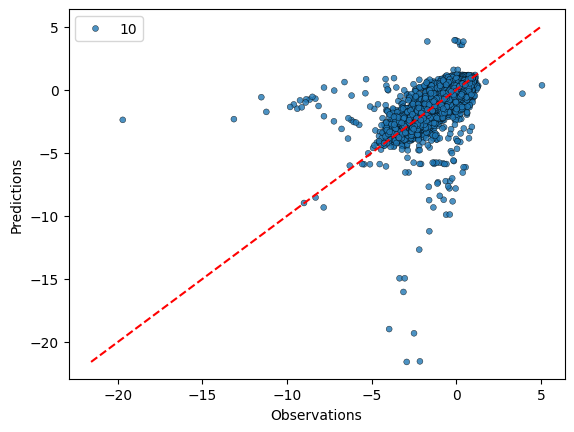

In [154]:
sns.scatterplot(results, x= y_test, y= y_pred, size= 10, alpha= 0.8, edgecolor= 'black')
plt.xlabel('Observations')
plt.ylabel('Predictions')

# Plot the one-to-one line (y = x)
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='1:1 Line')

In [137]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 0.7301637716953143
R-squared: 0.4959827562822602


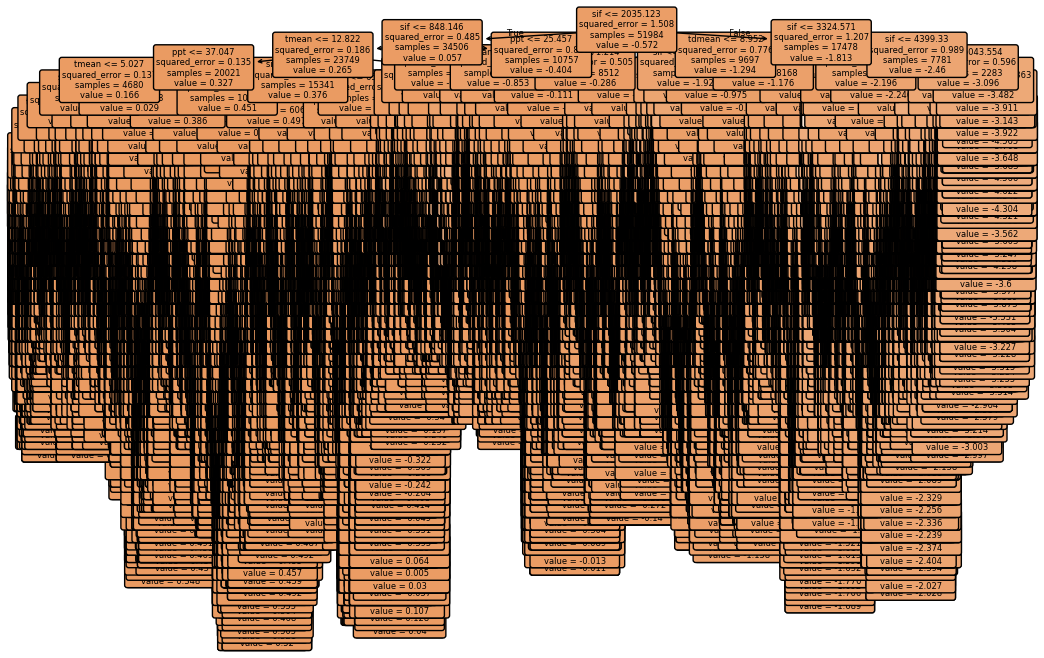

In [138]:
# Set figure size for better visibility
plt.figure(figsize=(12, 8))

# Plot the regression tree
plot_tree(regressor, 
          feature_names=x_vars,  # Names of the features
          filled=True,  # Fills nodes with color based on the output
          rounded=True,  # Rounds the node boxes
          fontsize=6)  # Font size for readability

# Show the plot
plt.show()

#### Decision Tree regressor, max_depth

In [168]:
# Initialize the Decision Tree Regressor
regressor = DecisionTreeRegressor(random_state=42, max_depth=8)

# Train the regressor
regressor.fit(X_train, y_train)

# Make predictions on the test set
y_pred = regressor.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 0.3958886073437467
R-squared: 0.7267261230595369


In [171]:
# Initialize the Decision Tree Regressor
regressor = DecisionTreeRegressor(random_state=42, max_depth=6)

# Train the regressor
regressor.fit(X_train, y_train)

# Make predictions on the test set
y_pred = regressor.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 0.4012599970134845
R-squared: 0.7230183617034929


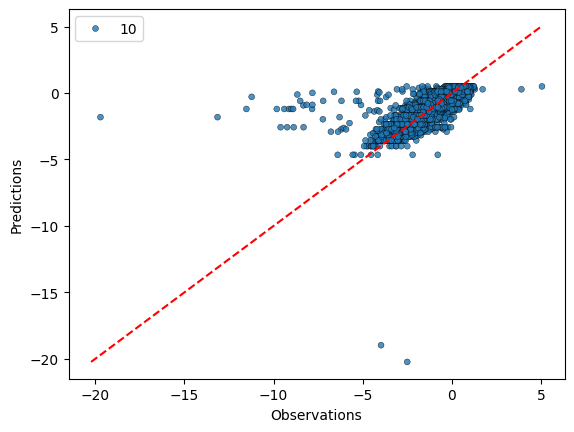

In [172]:
sns.scatterplot(results, x= y_test, y= y_pred, size= 10, alpha= 0.8, edgecolor= 'black')
plt.xlabel('Observations')
plt.ylabel('Predictions')

# Plot the one-to-one line (y = x)
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='1:1 Line')

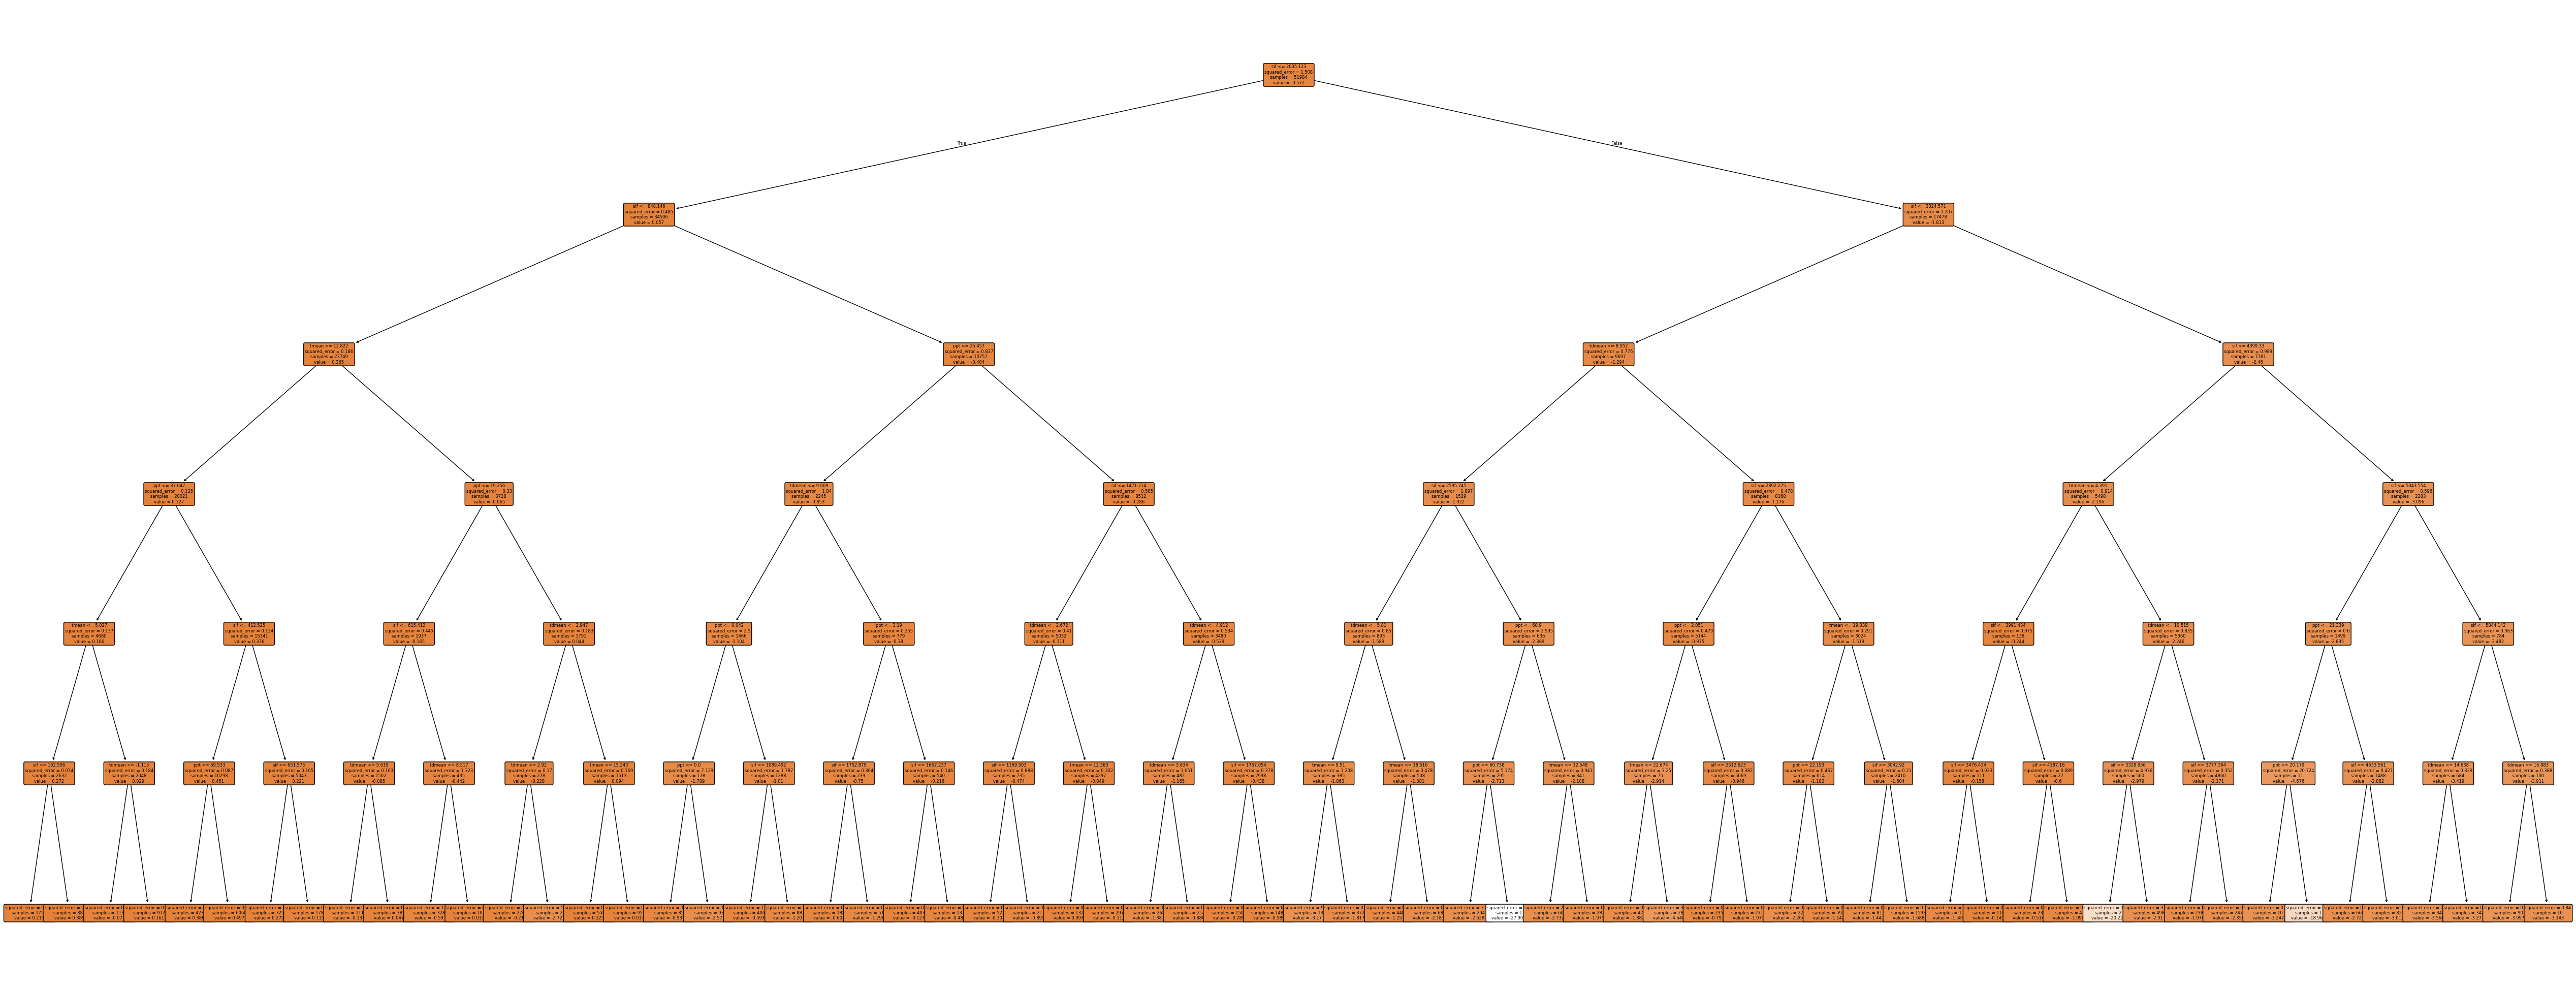

In [179]:
plt.figure(figsize=(65, 25))
plot_tree(regressor, 
          feature_names=x_vars,  # Names of the features
          filled=True,  # Fills nodes with color based on the output
          rounded=True,  # Rounds the node boxes
          fontsize=6)
plt.show()

### Random Forest

In [158]:
# Initialize the Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the Random Forest model
rf_regressor.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_regressor.predict(X_test)

In [161]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 0.35239010468518644
R-squared: 0.7567522572854415


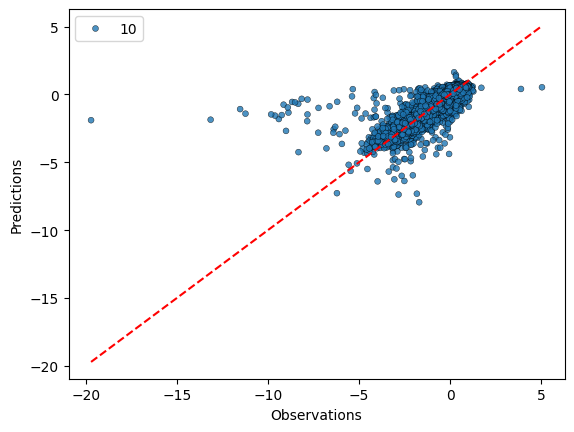

In [162]:
sns.scatterplot(results, x= y_test, y= y_pred, size= 10, alpha= 0.8, edgecolor= 'black')
plt.xlabel('Observations')
plt.ylabel('Predictions')

# Plot the one-to-one line (y = x)
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='1:1 Line')

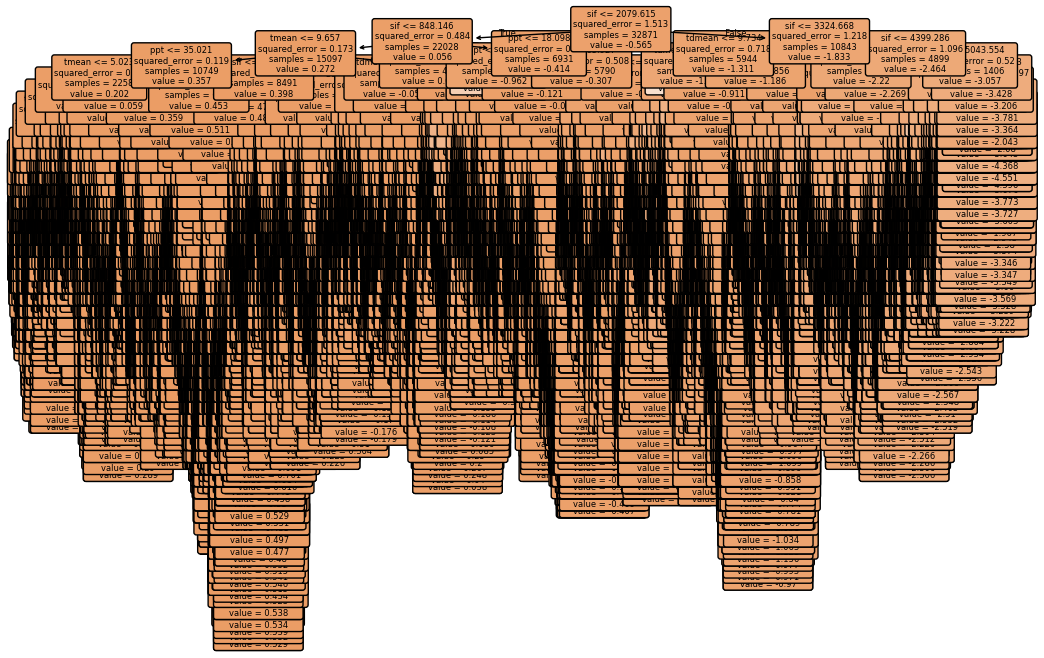

In [163]:
# Set figure size for better visibility
plt.figure(figsize=(12, 8))

# Plot the regression tree
plot_tree(rf_regressor.estimators_[45], # the 45th tree
          feature_names=x_vars,  # Names of the features
          filled=True,  # Fills nodes with color based on the output
          rounded=True,  # Rounds the node boxes
          fontsize=6)  # Font size for readability

# Show the plot
plt.show()

#### change hyperparameter

Mean Squared Error: 0.344369939934355
R-squared: 0.7622884143622172


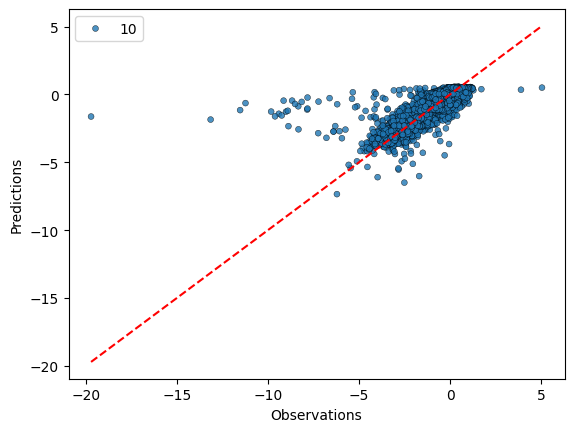

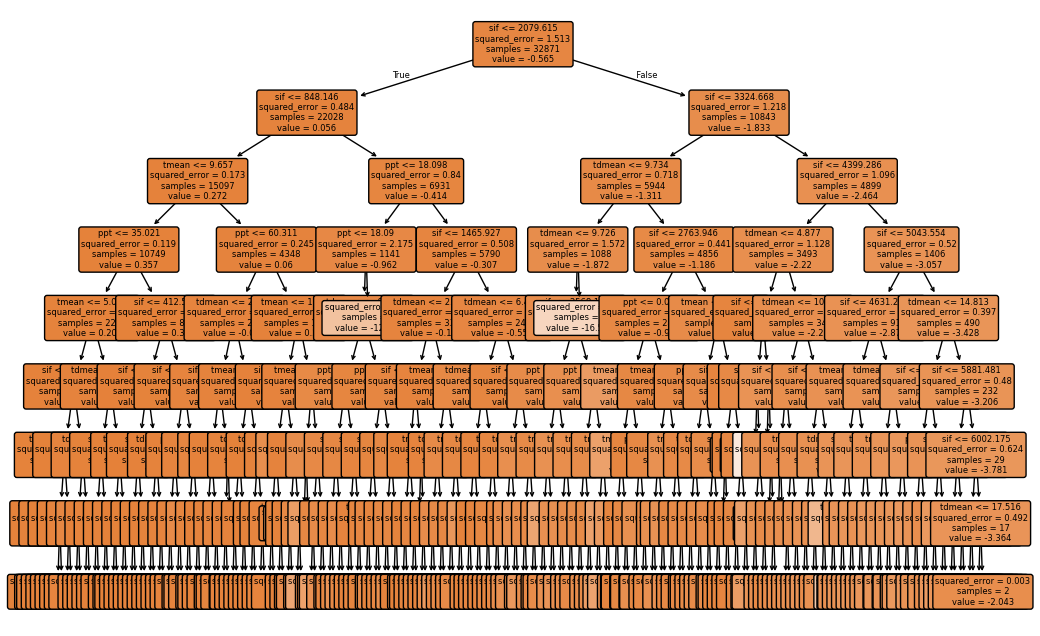

In [164]:
# Initialize the Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, max_depth = 8, random_state=42)

# Train the Random Forest model
rf_regressor.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_regressor.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

sns.scatterplot(results, x= y_test, y= y_pred, size= 10, alpha= 0.8, edgecolor= 'black')
plt.xlabel('Observations')
plt.ylabel('Predictions')

# Plot the one-to-one line (y = x)
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='1:1 Line')

# Set figure size for better visibility
plt.figure(figsize=(12, 8))

# Plot the regression tree
plot_tree(rf_regressor.estimators_[45], # the 45th tree
          feature_names=x_vars,  # Names of the features
          filled=True,  # Fills nodes with color based on the output
          rounded=True,  # Rounds the node boxes
          fontsize=6)  # Font size for readability

# Show the plot
plt.show()

In [167]:

# Check feature importance
import numpy as np
print("Feature Importance:", rf_regressor.feature_importances_)



Feature Importance: [0.049 0.03  0.054 0.867]
